In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from sklearn.decomposition import PCA
from scipy.stats import chi2
from sklearn.mixture import GaussianMixture

# Classificador

In [2]:
def matriz_conf(y_true, y_pred, labels):
    total_labels = labels
    print(total_labels)
    cm = np.zeros((len(total_labels),len(total_labels)), dtype=int)
    for i in range(len(y_true)):
        cm[y_true[i]][y_pred[i]] += 1
    
    cm = pd.DataFrame(cm, columns=total_labels, index=total_labels)

    cm_transp = pd.DataFrame(np.transpose(cm.to_numpy()), columns=total_labels, index=total_labels)

    for c in cm_transp.columns:
        cm_transp[c] = cm_transp[c]/cm_transp[c].sum()

    cm_porcento = pd.DataFrame(np.transpose(cm_transp.to_numpy()), columns=total_labels, index=total_labels)

    return cm, cm_porcento

def acc(cm, hidden_classes):
    cm_transp = pd.DataFrame(np.transpose(cm.dropna().to_numpy()), columns=cm.columns, index=cm.columns)
    acc = 0
    total = 0
    for c in cm_transp.columns:
        if c not in hidden_classes:
            acc += cm_transp[c][c]
        else:
            acc += cm_transp[c][-1]
        total += cm_transp[c].sum()
    return acc/total

# Calcula CM para todos

In [3]:
filenames = [0,2,3,4,5]

labels_str = ['DDoS', 'Benign', 'DoS', 'BruteForce', 'Bot', 'Web']

filenames

# pd.set_option('future.no_silent_downcasting', True)

[0, 2, 3, 4, 5]

0


Label
1    514148
2    329224
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


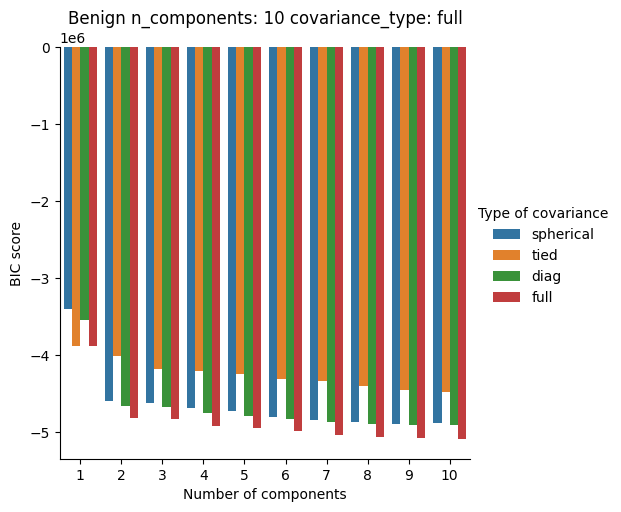

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


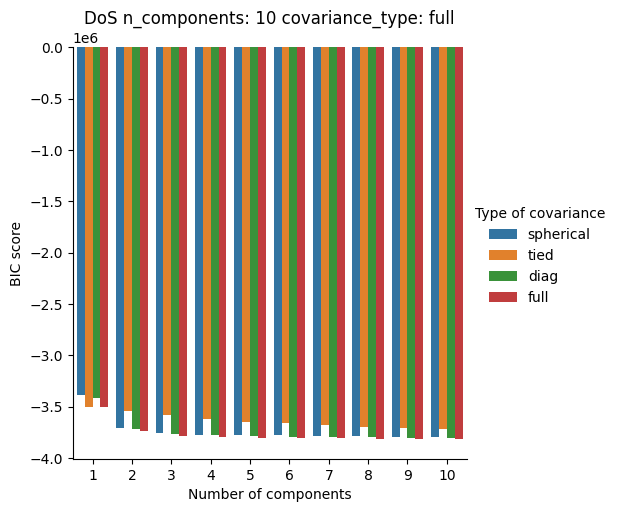

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 10 covariance_type: full


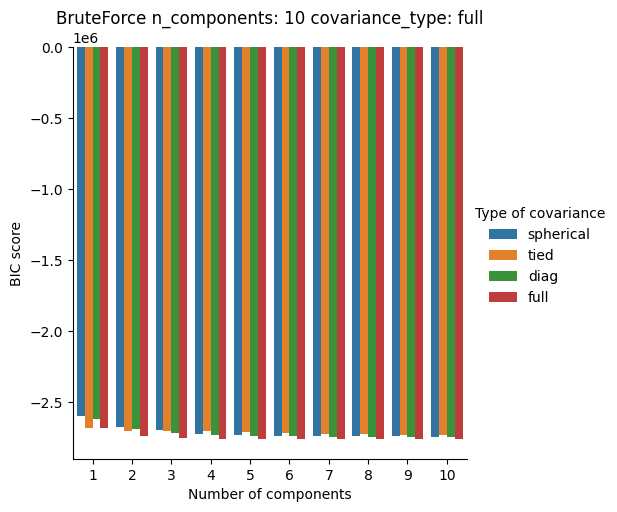

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


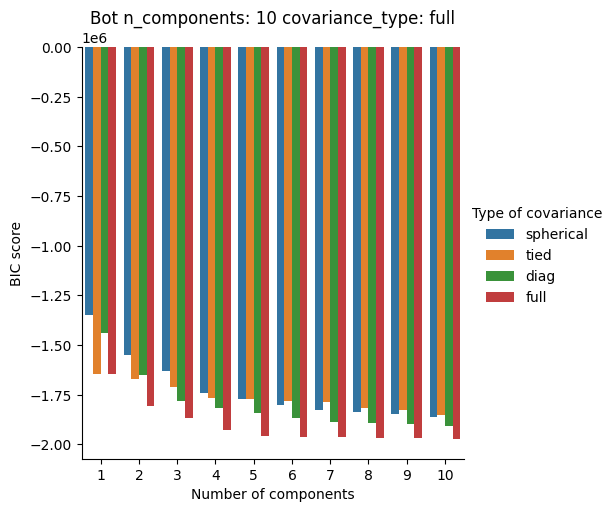

Tipo: 5 = Web
Melhor modelo: n_componentes: 7 covariance_type: full


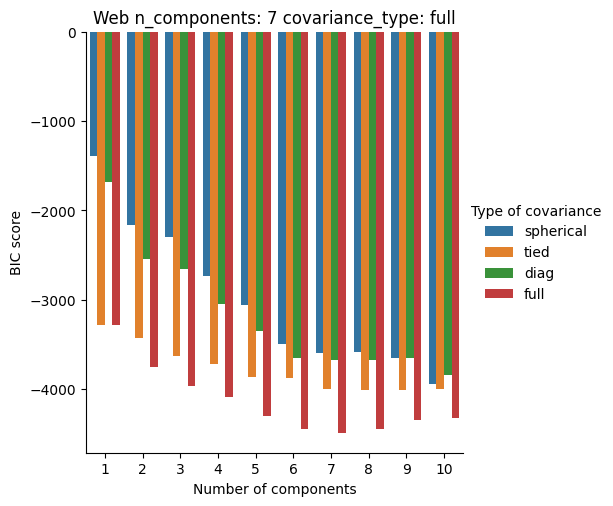

,0,1,2,3,4,5
0,NaN,19.037077,-40.472302,-188.877608,9.128370,-35.279476
1,NaN,8.730561,29.737802,6.764225,-35.680971,-29.461149
2,NaN,26.679037,-38.395755,-170.484737,7.533032,-30.227063
3,NaN,-2.049385,-13.101653,27.542953,-147.246507,-198.236624
4,NaN,27.214033,-26.932707,-174.958458,6.903727,-15.676601
...,...,...,...,...,...,...
519951,NaN,25.666636,-29.369349,-175.439080,9.920035,-15.062171
519952,NaN,10.594513,-113.553060,-496.527487,28.519863,4.911174
519953,NaN,17.313681,-6.760639,-135.766424,7.657349,13.716579
519954,NaN,26.362173,-11.321503,-173.575818,3.108413,-2.297291


,0,1,2,3,4,5
0,NaN,17.435034,-8.008921,-142.967266,8.427656,13.339063
1,NaN,18.824053,-40.567444,-186.554675,8.950015,-35.818683
2,NaN,25.667412,-32.241874,-151.417279,9.505035,-18.409724
3,NaN,26.653913,-27.931060,-162.618970,10.013709,-12.889376
4,NaN,8.260569,-28.288042,-77.408378,7.271066,-18.635101
...,...,...,...,...,...,...
649942,NaN,27.238723,-27.007022,-175.393960,6.933240,-15.645270
649943,NaN,7.526914,-22.003794,-60.181292,3.784075,-14.603714
649944,NaN,7.635310,-22.892799,-62.801907,4.517548,-14.998029
649945,NaN,-1.603815,-12.323753,28.903806,-146.375592,-205.590823


2


Label
0    808919
1    514148
3    243806
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS


d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Melhor modelo: n_componentes: 10 covariance_type: full


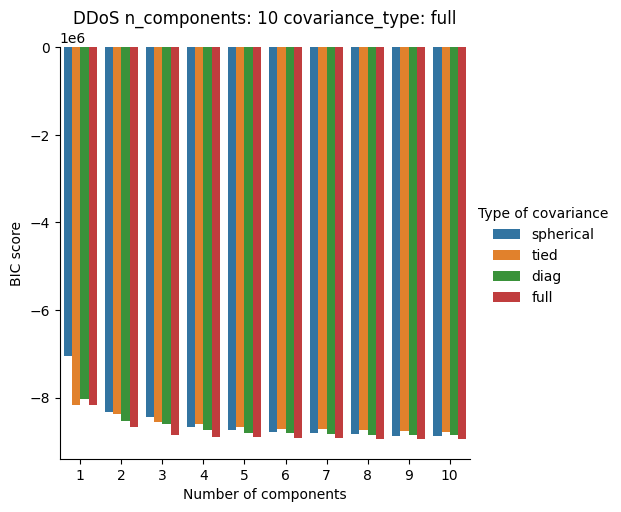

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


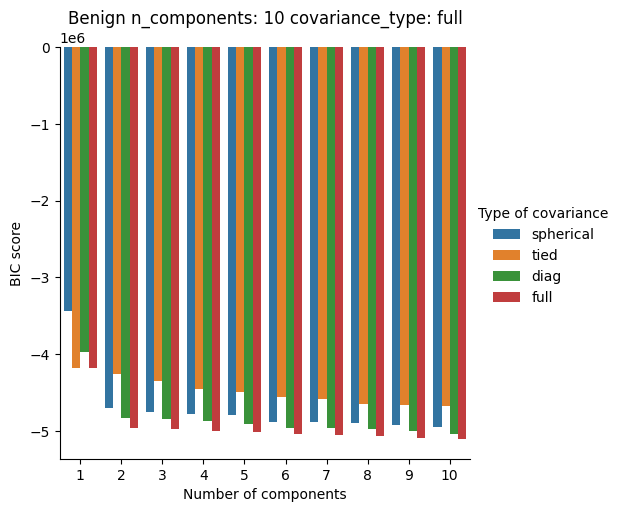

Tipo: 3 = BruteForce


d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Melhor modelo: n_componentes: 6 covariance_type: full


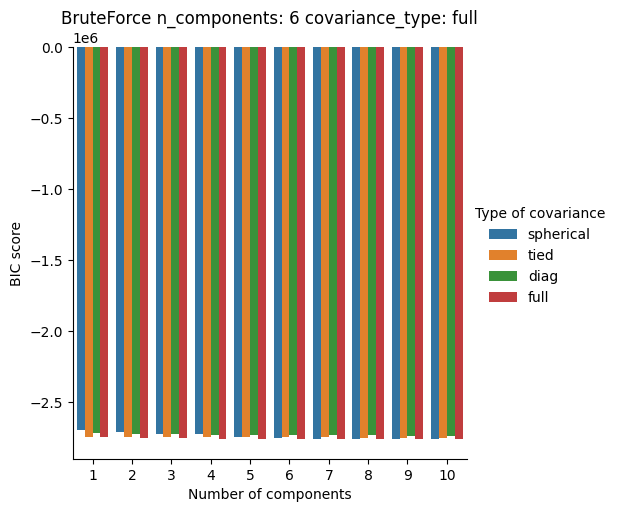

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


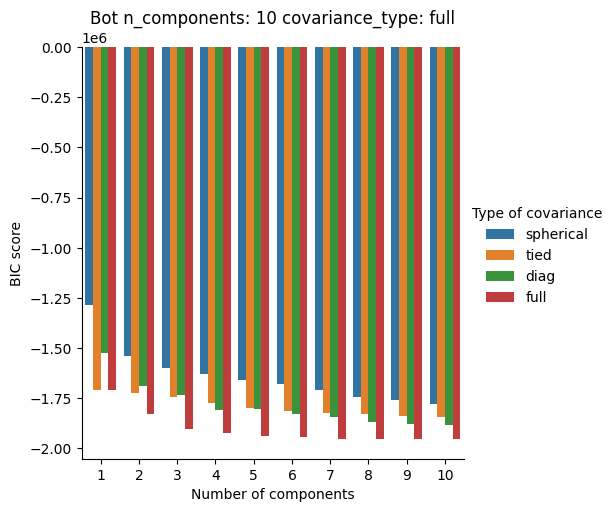

Tipo: 5 = Web
Melhor modelo: n_componentes: 8 covariance_type: tied


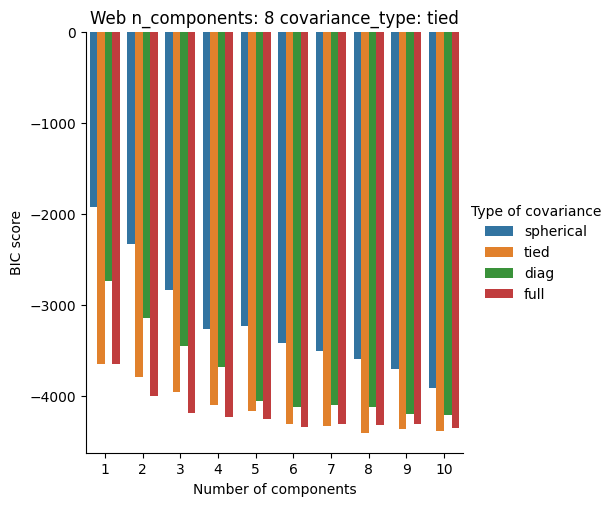

,0,1,2,3,4,5
0,28.011991,8.994840,NaN,-3667.984892,-9.387840,10.257957
1,-2.259860,16.025318,NaN,16.127315,9.942957,-7.181444
2,-115.208908,25.817856,NaN,-377.772328,9.379284,7.999435
3,-1007.305489,-10.209679,NaN,28.108122,-0.883035,-34.247218
4,-103.086889,26.743927,NaN,-397.092639,11.058640,-5.460012
...,...,...,...,...,...,...
519951,-118.077057,26.396764,NaN,-385.446101,13.450146,4.808973
519952,-683.820569,14.154403,NaN,-11078.862176,28.234755,15.819871
519953,28.161059,8.994622,NaN,-3744.301573,-10.563974,10.423312
519954,-106.279924,26.774833,NaN,-349.243622,12.893180,1.550426


,0,1,2,3,4,5
0,27.825738,9.061175,NaN,-3806.533737,-10.250953,10.858965
1,28.022471,9.013392,NaN,-3670.645632,-9.328356,10.266148
2,-114.061440,25.738635,NaN,-400.061882,10.495893,7.078663
3,-119.608422,23.977177,NaN,-447.212700,13.179425,5.372659
4,27.554281,8.036633,NaN,-3774.440342,-12.148434,10.608054
...,...,...,...,...,...,...
649942,-102.913817,26.746688,NaN,-383.943292,11.021852,-5.528023
649943,27.512823,8.035615,NaN,-3782.375116,-12.128675,10.723859
649944,27.582360,8.029733,NaN,-3776.097253,-12.176599,10.617303
649945,-999.525741,-9.642532,NaN,28.898002,-1.372034,-34.356819


3


Label
0    808919
1    514148
2    329224
4    183163
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


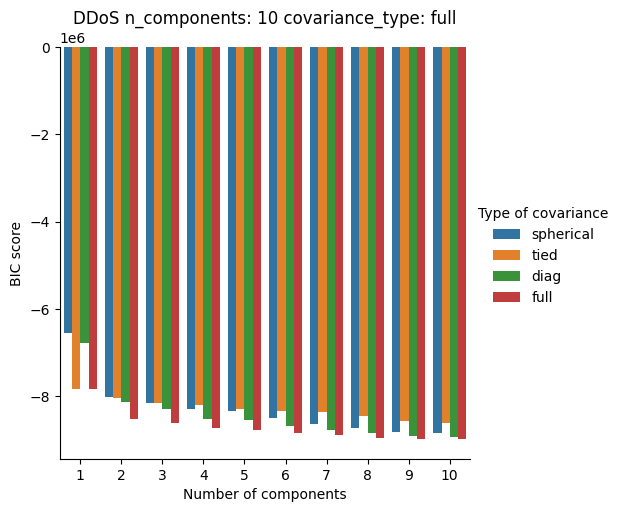

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


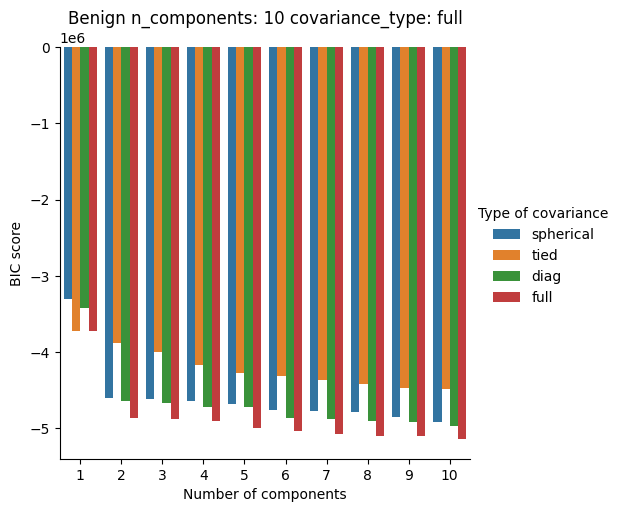

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


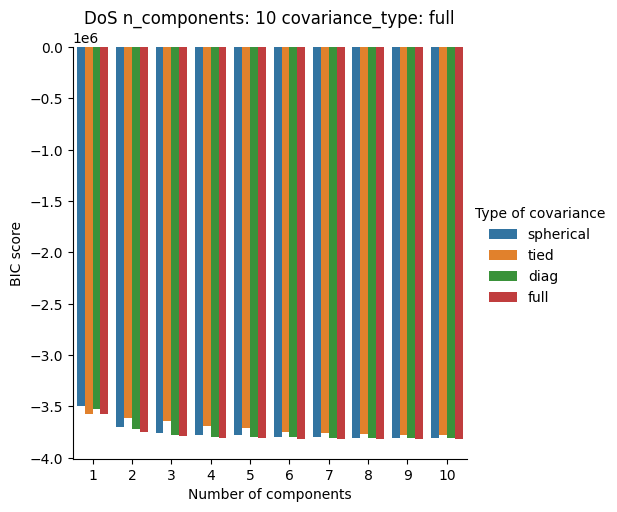

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


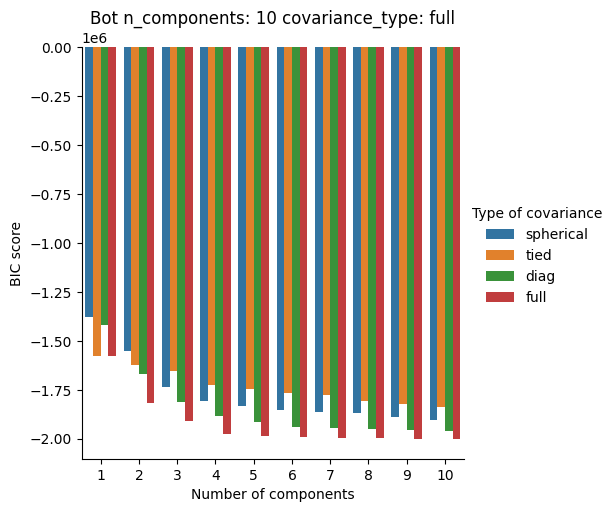

Tipo: 5 = Web
Melhor modelo: n_componentes: 10 covariance_type: diag


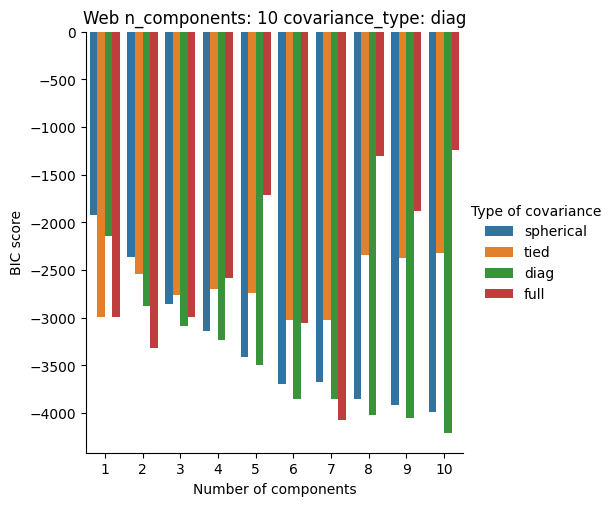

,0,1,2,3,4,5
0,28.424987,6.436020,-1579.876961,NaN,2.318181,1.827426
1,-5.477672,4.460175,29.666674,NaN,-220.787282,-6.724143
2,-0.450998,24.904363,-20.702623,NaN,12.963761,6.354658
3,5.096272,13.937782,14.008448,NaN,-74.531696,-0.192828
4,7.786282,27.465945,-13.972047,NaN,11.027441,6.339817
...,...,...,...,...,...,...
519951,1.212072,25.316807,-12.663632,NaN,13.877815,6.227557
519952,-87.187119,2.521504,-923.989387,NaN,28.873755,18.314853
519953,28.334730,11.199481,-1627.643214,NaN,5.118858,1.647520
519954,5.614288,26.536319,-14.531490,NaN,4.414572,6.615830


,0,1,2,3,4,5
0,27.854197,12.353272,-1616.147627,NaN,5.204784,1.997328
1,28.383864,6.339692,-1581.049409,NaN,2.306588,1.795188
2,-1.888086,23.625941,-18.831781,NaN,12.176137,6.200544
3,-0.039271,25.219363,-12.599752,NaN,13.658166,6.191908
4,27.033045,3.024029,-1675.047487,NaN,1.760105,0.257845
...,...,...,...,...,...,...
649942,8.063475,27.448261,-14.003082,NaN,11.234375,6.334990
649943,27.367950,3.225177,-1673.599509,NaN,1.759365,0.321700
649944,27.499105,3.473120,-1671.822073,NaN,1.795331,0.377117
649945,-6.982173,9.899587,-37.407832,NaN,-2.861757,7.290186


4


Label
0    808919
1    514148
2    329224
3    243806
5       596
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


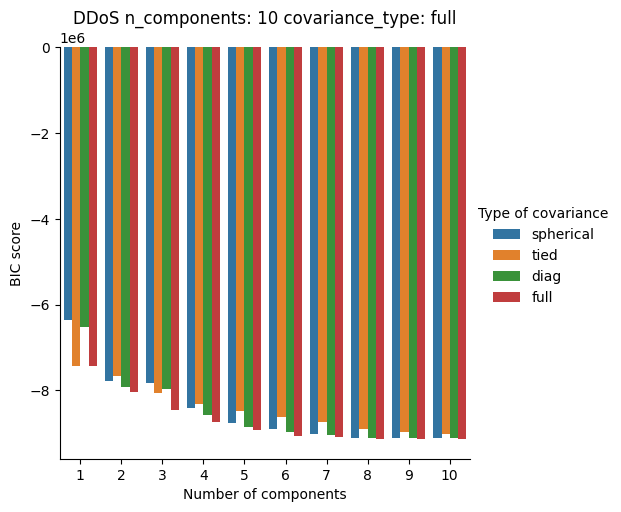

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


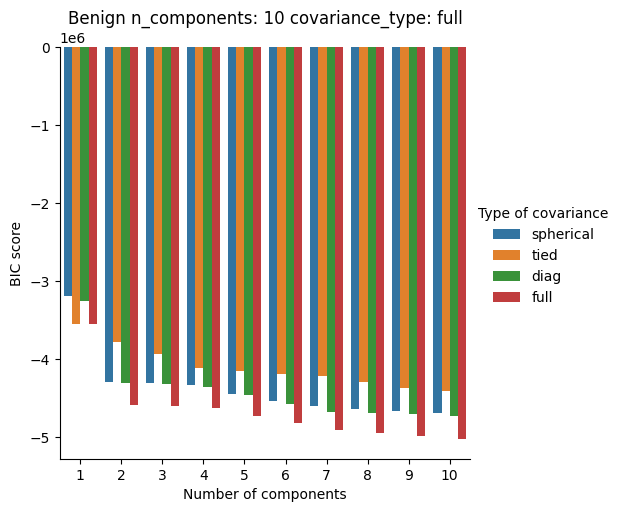

Tipo: 2 = DoS
Melhor modelo: n_componentes: 9 covariance_type: full


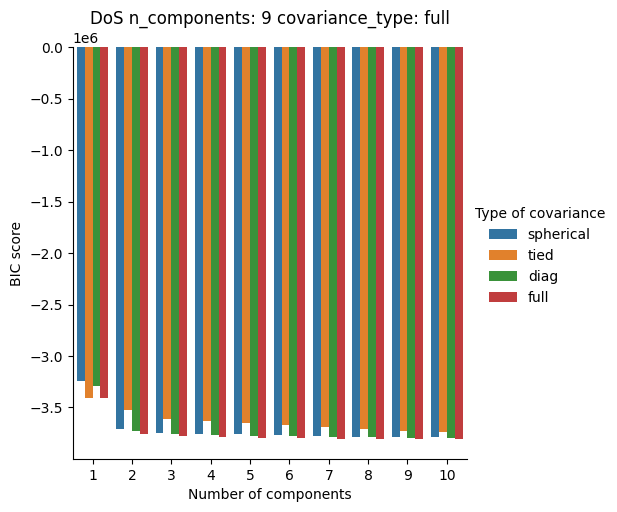

Tipo: 3 = BruteForce


d:\Downloads\Mestrado\Experimentos\env\Lib\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


Melhor modelo: n_componentes: 5 covariance_type: full


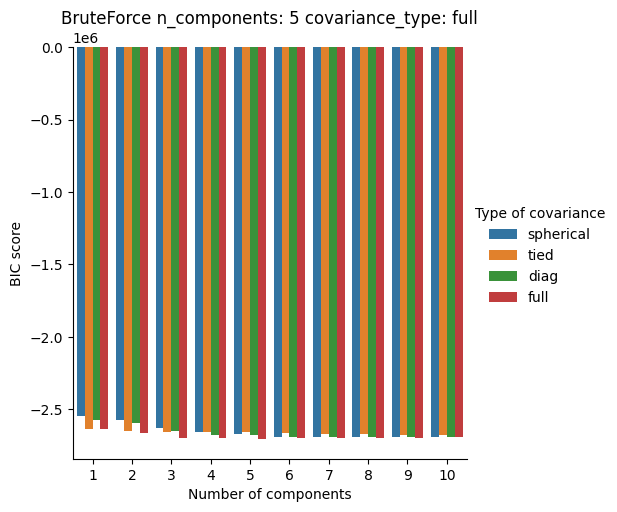

Tipo: 5 = Web
Melhor modelo: n_componentes: 4 covariance_type: full


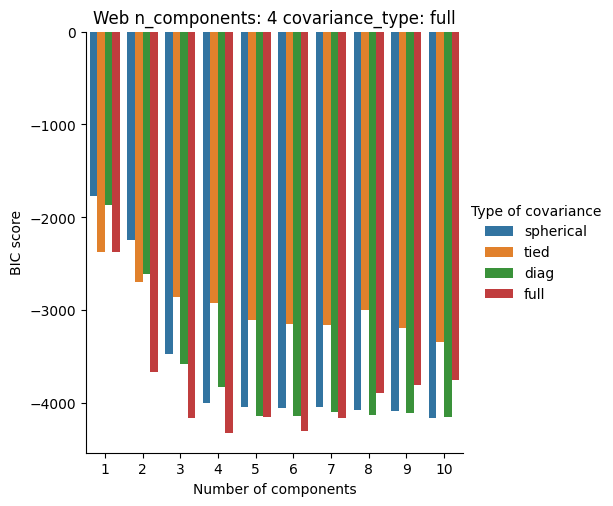

,0,1,2,3,4,5
0,28.455885,3.082015,-2839.959225,-11109.730871,NaN,-15.395490
1,-3529.832707,-14.996882,29.686550,-56.099692,NaN,-49.213079
2,-69.947203,25.853371,-44.760069,-521.534897,NaN,-23.294400
3,-5051.409865,-52.965206,-208.409504,27.513619,NaN,-252.393146
4,-49.830433,26.727140,-39.986069,-494.124275,NaN,-8.115920
...,...,...,...,...,...,...
519951,-70.146742,26.226474,-40.631026,-520.993601,NaN,-16.460587
519952,-90.936972,22.596164,-43.186668,-523.194418,NaN,-17.727595
519953,28.869661,4.945286,-2878.727147,-11710.293635,NaN,-10.439483
519954,-105.134779,24.146416,-40.543228,-562.471034,NaN,-23.718281


,0,1,2,3,4,5
0,28.837685,5.033067,-2872.767559,-11689.060999,NaN,-10.154645
1,28.439657,3.050950,-2842.566175,-11118.061628,NaN,-15.373648
2,-69.410246,25.348512,-42.848219,-511.867083,NaN,-19.779856
3,-71.176728,25.954063,-40.511082,-505.849665,NaN,-17.722903
4,27.882434,6.257105,-2866.634507,-11463.090932,NaN,-9.056962
...,...,...,...,...,...,...
649942,-48.239977,26.718671,-40.143758,-492.962237,NaN,-8.568581
649943,27.870460,6.252122,-2866.934991,-11466.378074,NaN,-9.149760
649944,27.891162,6.243196,-2868.532350,-11471.007722,NaN,-9.115985
649945,-4927.524559,-53.105050,-208.817623,28.159376,NaN,-244.146822


5


Label
0    808919
1    514148
2    329224
3    243806
4    183163
Name: count, dtype: int64

Tipo: 0 = DDoS
Melhor modelo: n_componentes: 10 covariance_type: full


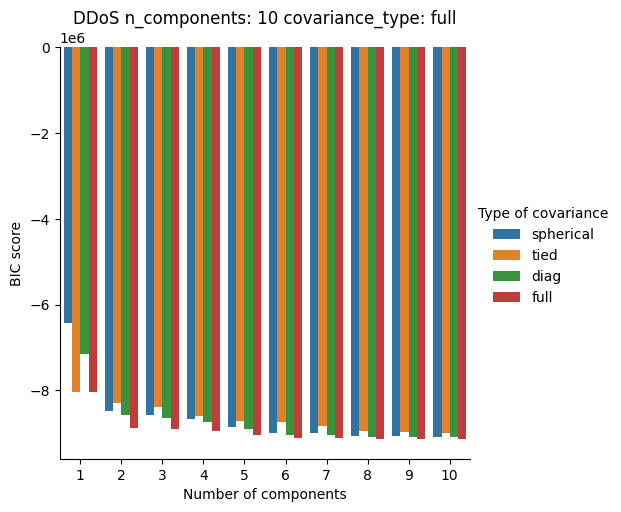

Tipo: 1 = Benign
Melhor modelo: n_componentes: 10 covariance_type: full


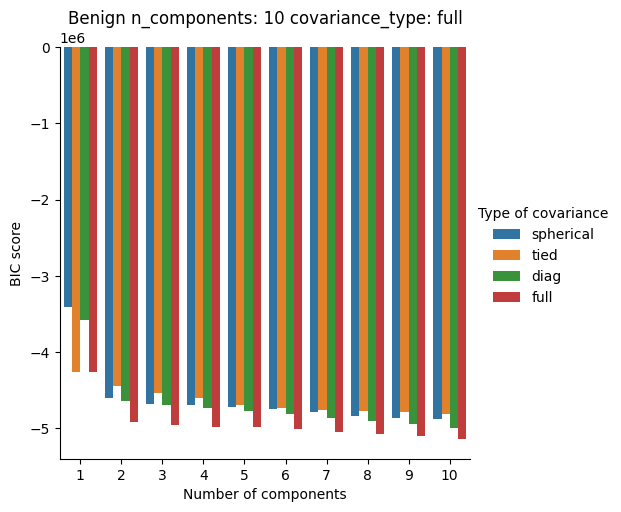

Tipo: 2 = DoS
Melhor modelo: n_componentes: 10 covariance_type: full


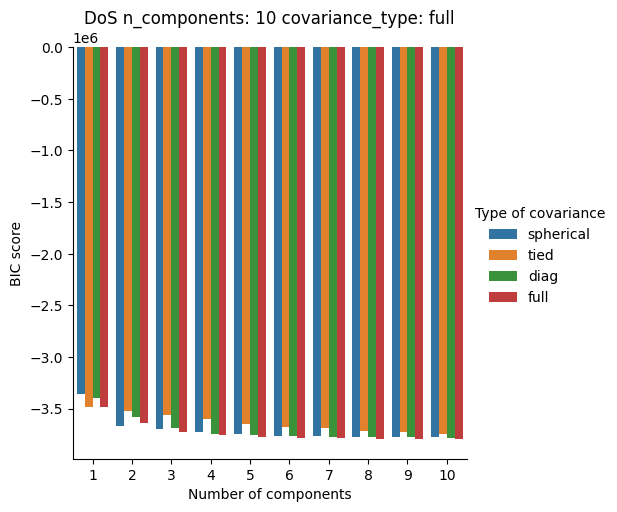

Tipo: 3 = BruteForce
Melhor modelo: n_componentes: 4 covariance_type: full


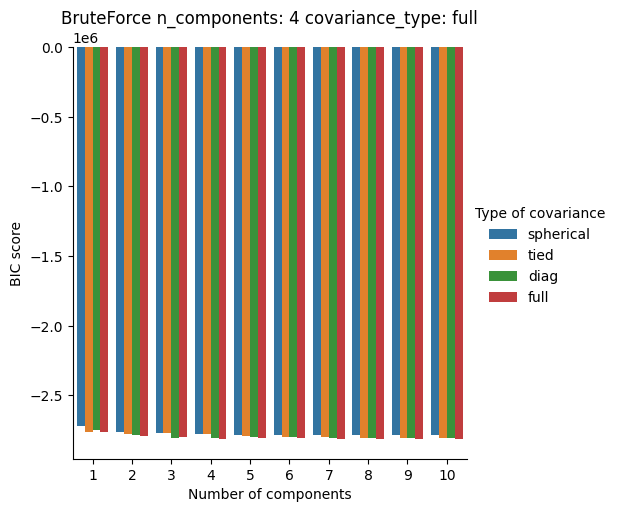

Tipo: 4 = Bot
Melhor modelo: n_componentes: 10 covariance_type: full


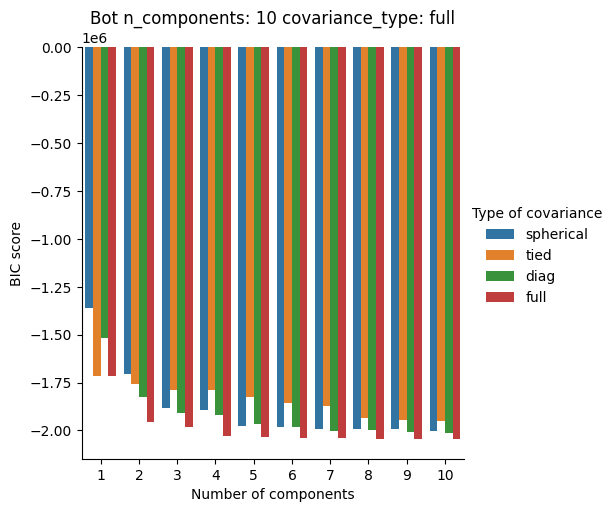

,0,1,2,3,4,5
0,28.303357,1.546124,-3001.879558,-4166.485850,-29.220232,NaN
1,-567.419139,8.883029,29.592515,-69.119971,-57.281955,NaN
2,-22.198992,24.735618,-967.332214,-1856.944031,8.029651,NaN
3,-1187.976633,-4.275677,-2920.536901,29.182852,-157.550317,NaN
4,-15.805805,26.876627,-1063.088382,-1818.272455,15.991183,NaN
...,...,...,...,...,...,...
519951,-18.686789,26.036876,-1063.016537,-1949.012246,9.820107,NaN
519952,-381.147224,11.500601,-12695.101786,-8793.212029,29.142738,NaN
519953,28.937015,2.488428,-2994.107995,-4032.172762,-26.806000,NaN
519954,-19.511490,26.098076,-1033.682020,-1756.941816,9.276346,NaN


,0,1,2,3,4,5
0,28.892856,2.495513,-3000.377550,-4037.081418,-27.145457,NaN
1,28.236899,1.530223,-3001.246787,-4168.622339,-30.304595,NaN
2,-20.418415,25.426332,-979.083523,-1846.494883,9.626768,NaN
3,-18.865577,25.678062,-1057.139673,-1936.795744,11.814383,NaN
4,26.848093,1.023466,-3073.379278,-4184.358352,-37.660837,NaN
...,...,...,...,...,...,...
649942,-15.821393,26.888326,-1063.107034,-1817.765405,16.093832,NaN
649943,27.415978,0.980344,-3051.869527,-4164.982949,-35.557674,NaN
649944,27.524380,0.979911,-3051.688509,-4168.867733,-36.831008,NaN
649945,-1172.647121,-4.393732,-2884.008151,28.581054,-160.334304,NaN


In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import os

def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    # Make it negative since GridSearchCV expects a score to maximize
    return -estimator.bic(X)


param_grid = {
    "n_components": range(1, 11),
    "covariance_type": ["spherical", "tied", "diag", "full"],
    "random_state": [123],
}

exp_train = []
exp_val = []
exp_test = []
y_true_all_exp_train = []
y_true_all_exp_val = []
y_true_all_exp_test = []
for z in range(len(filenames)):
    
    train_encoded_df = pd.read_csv(f'train_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    val_encoded_df = pd.read_csv(f'val_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    test_encoded_df = pd.read_csv(f'test_encoded_CADE_cod_joined_attacks_pick_class_squared_normalized_{filenames[z]}_hidden.csv')
    y_true_all_exp_train.append(train_encoded_df['Label'].values.tolist())
    y_true_all_exp_val.append(val_encoded_df['Label'].values.tolist())
    y_true_all_exp_test.append(test_encoded_df['Label'].values.tolist())
    print(filenames[z])
    hidden_classes = [filenames[z]] # Classes ocultas do treinamento
    for i in range(len(labels_str)):
        train_encoded_df['Label'] = train_encoded_df['Label'].replace(labels_str[i],i)
        val_encoded_df['Label'] = val_encoded_df['Label'].replace(labels_str[i],i)
        test_encoded_df['Label'] = test_encoded_df['Label'].replace(labels_str[i],i)

    display(train_encoded_df['Label'].value_counts())
        
    
        
    gmms = []
    for i in range(len(labels_str)):
        if i not in hidden_classes:
            print(f'Tipo: {i} = {labels_str[i]}')
            grid_search = GridSearchCV(
                GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
            )
            grid_search.fit(train_encoded_df[train_encoded_df['Label'] == i].drop(columns=['Label']).to_numpy())
            print(f"Melhor modelo: n_componentes: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            gmms.append(grid_search.best_estimator_)
            df = pd.DataFrame(grid_search.cv_results_)[
                ["param_n_components", "param_covariance_type", "mean_test_score"]
            ]
            df["mean_test_score"] = -df["mean_test_score"]
            df = df.rename(
                columns={
                    "param_n_components": "Number of components",
                    "param_covariance_type": "Type of covariance",
                    "mean_test_score": "BIC score",
                }
            )
            df.sort_values(by="BIC score").head()
            sns.catplot(
                data=df,
                kind="bar",
                x="Number of components",
                y="BIC score",
                hue="Type of covariance",
                
            ).set(title = f"{labels_str[i]} n_components: {grid_search.best_params_['n_components']} covariance_type: {grid_search.best_params_['covariance_type']}")
            plt.show()
            # plt.savefig(f'class_{i}_train_{filenames[z]}_GMM_BIC_1_10_scores.png')
        else:
            gmms.append(None)
    
    # scores = []
    # for i, row in train_encoded_df.drop(columns=['Label']).iterrows():
    #     max_dist = -np.inf
    #     pred = -1
    #     scores.append([])
    #     for j in range(len(labels_str)):
    #         if j not in hidden_classes:
    #             inside = False
    #             max = -np.inf
    #             # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
    #             score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
    #             scores[i].append(score)
    #         else:
    #             scores[i].append(np.nan)
    
    
    # display(pd.DataFrame(scores))
    # exp_train.append(scores)
    #pd.DataFrame(scores).to_csv(f'train_{filenames[z]}_GMM_BIC_1_10_scores.csv',index=False)

    scores = []
    for i, row in val_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_val.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = val_encoded_df["Label"].values
    scores_df.to_csv(f'val_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)

    scores = []
    for i, row in test_encoded_df.drop(columns=['Label']).iterrows():
        max_dist = -np.inf
        pred = -1
        scores.append([])
        for j in range(len(labels_str)):
            if j not in hidden_classes:
                inside = False
                max = -np.inf
                # score = np.exp(gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0])*priors[j]
                score = gmms[j].score_samples(row.to_numpy().reshape(1, -1))[0]
                scores[i].append(score)
            else:
                scores[i].append(np.nan)
    
    
    display(pd.DataFrame(scores))
    exp_test.append(scores)
    scores_df = pd.DataFrame(scores)
    scores_df['Label'] = test_encoded_df["Label"].values
    scores_df.to_csv(f'test_{filenames[z]}_GMM_BIC_1_10_scores.csv', index=False)